# What is FEniCS?

**FEniCS** is a Python-based framework for solving differential equations using the **finite element method (FEM)**.

Instead of writing all the linear algebra and element-by-element assembly by hand, FEniCS lets us describe a problem almost exactly as we write it in mathematics:
- define the **mesh**
- define the **function space**
- write the **weak form**
- apply **boundary conditions**
- solve for the unknown field

This makes FEniCS very useful for teaching, prototyping, and research, because it connects the mathematical formulation of FEM directly to code.

In simple terms:

- **Mathematics:** write the PDE in weak form
- **FEniCS:** turns that weak form into a solvable linear system
- **Result:** we obtain a numerical approximation to the solution on the mesh

For us, FEniCS is helpful because it allows us to focus on the **ideas of finite elements**—basis functions, weak forms, trial and test functions, and boundary conditions—without getting lost in low-level implementation details.

## Creating the MESH

```python
mesh = UnitSquareMesh(20, 20)

This creates a **2D square mesh** over the domain from $x=0$ to $x=1$ and from $y=0$ to $y=1$.

More specifically:

* `UnitSquareMesh` means: build a mesh on the **unit square** $[0,1]\times[0,1]$
* `(20, 20)` means: divide the square into **20 parts in the $x$ direction** and **20 parts in the $y$ direction**

So this line tells FEniCS:

> “Create the computational domain, and break it into many small elements so we can approximate the solution on it.”

In finite elements, the mesh is the collection of small pieces (usually triangles in 2D) on which the solution is represented approximately.

So after this line:

* the **domain** is defined
* the square is subdivided into small elements
* FEniCS stores that grid in the variable `mesh`

You can think of it as the geometric foundation of the whole problem: before solving a PDE, we must first decide **where** we are solving it and **how finely** we divide that region.



## Function space

```python
V = FunctionSpace(mesh, "P", 1)
````

This line defines the **function space** in which FEniCS will look for the numerical solution.

In finite elements, we do not search for the exact continuous solution among all possible functions. Instead, we restrict the problem to a smaller space of approximate functions built on the mesh.

Here:

* `mesh` tells FEniCS on which geometric grid the functions are defined
* `"P"` means **Lagrange polynomial elements**
* `1` means **degree 1**, so the solution is approximated with **linear functions** on each element

So this creates a space of functions that are:

* defined on the mesh
* continuous from one element to the next
* linear inside each element

In practical terms, this means the solution is determined by its values at the mesh nodes, and inside each triangle FEniCS interpolates those nodal values using linear basis functions.

So the variable `V` represents the set of all admissible approximate solutions we allow in the computation. It is the mathematical space where the finite element solution will live.

```
```


## Building the system of equations
```python
u = TrialFunction(V)
v = TestFunction(V)
f = Constant(1.0)

a = dot(grad(u), grad(v)) * dx
L = f * v * dx
````

These lines define the **finite element problem in weak form**.

First, we introduce two special functions:

* `u = TrialFunction(V)` is the **unknown solution** we want to solve for
* `v = TestFunction(V)` is an arbitrary **test function** used to build the weak form
* `f = Constant(1.0)` defines the right-hand side source term, here taken as the constant value $1$

The important idea is that in the weak form, we do not work directly with the strong equation. Instead, we multiply by a test function and integrate over the domain.

The next two lines define the two sides of the variational problem:

* `a = dot(grad(u), grad(v)) * dx`
* `L = f * v * dx`

Here:

* `grad(u)` is the gradient of the unknown function
* `grad(v)` is the gradient of the test function
* `dot(grad(u), grad(v))` is their dot product
* `dx` means integration over the whole domain

So

$$
a = \int_{\Omega} \nabla u \cdot \nabla v  dx
$$

and

$$
L = \int_{\Omega} f v  dx
$$

This means that FEniCS is being told to solve the weak problem:

$$
\int_{\Omega} \nabla u \cdot \nabla v  dx
=

\int_{\Omega} f v  dx
\qquad \text{for all test functions } v
$$

The object `a` is called a **bilinear form** because it depends on both $u$ and $v$, and `L` is called a **linear form** because it depends only on $v$.

So, in short, these lines translate the mathematical weak form of the PDE into the language that FEniCS understands.

```
```


## Adding boundary conditions

```python
u_D = Constant(0.0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)
print("Boundary condition created.")
````

These lines define and apply a **Dirichlet boundary condition**.

First,

```python
u_D = Constant(0.0)
```

sets the prescribed boundary value to zero. This means we want the solution to satisfy

$$
u = 0
\quad \text{on the boundary.}
$$

Next,

```python
def boundary(x, on_boundary):
    return on_boundary
```

defines a function that tells FEniCS which points belong to the boundary of the domain.

Here:

* `x` is the coordinate of a point
* `on_boundary` is a Boolean value provided by FEniCS
* returning `on_boundary` means: **select all points that lie on the outer boundary**

So this function says:

> “Apply the boundary condition everywhere on the boundary of the square.”

Then,

```python
bc = DirichletBC(V, u_D, boundary)
```

creates the actual boundary condition object.

This tells FEniCS:

* use the function space `V`
* impose the value `u_D = 0`
* apply it on the part of the domain identified by `boundary`

In other words, this enforces that the finite element solution must be zero all around the edge of the domain.



## Assembly and solving

```python
uh = Function(V)
solve(a == L, uh, bc)
````

These lines create the finite element solution and ask FEniCS to solve the problem.

First,

```python
uh = Function(V)
```

creates a function in the space `V` that will store the numerical solution.

The notation `uh` is often used in finite elements to mean:

* $u$ = the exact mathematical solution
* $u_h$ = the finite element approximation on a mesh of size $h$

So `uh` is the approximate solution that FEniCS will compute.

Next,

```python
solve(a == L, uh, bc)
```

tells FEniCS to solve the variational problem

$$
a(u,v) = L(v)
$$

subject to the boundary condition `bc`.

In this case, that means FEniCS will:

* assemble the linear system coming from the weak form
* apply the Dirichlet boundary condition
* solve for the unknown coefficients of `uh`

Since we are using linear finite elements, those unknown coefficients are essentially the values of the solution at the mesh nodes.

After this line, `uh` contains the computed approximate solution over the whole domain.



## Extracting the solution from the mesh

```python
vertex_values = uh.compute_vertex_values(mesh)
print("Minimum value:", vertex_values.min())
print("Maximum value:", vertex_values.max())
````

These lines extract the computed solution at the **mesh vertices** and then report its smallest and largest values.

First,

```python
vertex_values = uh.compute_vertex_values(mesh)
```

takes the finite element solution `uh` and evaluates it at the mesh nodes (the vertices of the elements). The result is stored as a numerical array called `vertex_values`.

This is useful because `uh` is a FEniCS function object, not just a simple list of numbers. By extracting the vertex values, we can inspect the solution more directly.

Then,

```python
print("Minimum value:", vertex_values.min())
print("Maximum value:", vertex_values.max())
```

compute and print:

* the minimum value of the numerical solution on the mesh vertices
* the maximum value of the numerical solution on the mesh vertices

So this gives us a quick summary of the range of the solution.

Conceptually, this is often used as a simple check:

* Is the solution positive or negative?
* Is the magnitude reasonable?
* Does the solution behave as expected for the PDE and boundary conditions?

In this example, since the boundary is fixed at zero and the source term is positive, these minimum and maximum values help us understand the overall shape and amplitude of the computed solution.

```
```


## A similar FEniCS script with a time derivative

If we want a PDE with both a **time derivative** and a **Laplacian**, a standard example is the **heat equation**:

$$
\frac{\partial u}{\partial t} - \Delta u = f
\quad \text{in } \Omega
$$

with boundary condition

$$
u = 0
\quad \text{on } \partial\Omega
$$

and an initial condition

$$
u(x,y,0) = u_0(x,y).
$$

A simple way to solve this in FEniCS is to discretize time with a **time-stepping method**, for example **backward Euler**:

$$
\frac{u^{n+1} - u^n}{\Delta t} - \Delta u^{n+1} = f.
$$

This means that at each time step we solve an elliptic problem similar to the Poisson equation, but with an additional term from the time derivative.

Here is a simple script:



In [1]:
from fenics import *

# Mesh and function space
mesh = UnitSquareMesh(20, 20)
V = FunctionSpace(mesh, "P", 1)

# Boundary condition u = 0 on the whole boundary
u_D = Constant(0.0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)

# Time step and final time
dt = 0.01
T = 0.2

# Source term
f = Constant(1.0)

# Initial condition
u_n = interpolate(Constant(0.0), V)

# Unknown and test function
u = TrialFunction(V)
v = TestFunction(V)

# Weak form for backward Euler
a = (u*v + dt*dot(grad(u), grad(v))) * dx
L = (u_n*v + dt*f*v) * dx

# Function to store the new solution
uh = Function(V)

# Time loop
t = 0.0
while t < T:
    t += dt
    solve(a == L, uh, bc)

    # Update previous solution
    u_n.assign(uh)

    print("time =", t)

print("Transient solution computed.")

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
time = 0.01
time = 0.02
time = 0.03
time = 0.04
time = 0.05
time = 0.060000000000000005
time = 0.07
time = 0.08
time = 0.09
time = 0.09999999999999999
time = 0.10999999999999999
time = 0.11999999999999998
time = 0.12999999999999998
time = 0.13999999999999999
time = 0.15
time = 0.16
time = 0.17
time = 0.18000000000000002
time = 0.19000000000000003
time = 0.20000000000000004
Transient solution computed.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational prob

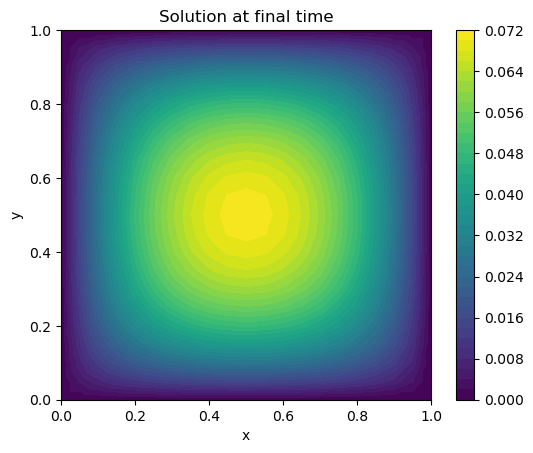

In [2]:
# Plotting the result of the transient heat-equation example
import matplotlib.pyplot as plt

plt.figure()
p = plot(uh)
plt.colorbar(p)
plt.title("Solution at final time")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


### What changes compared with the Poisson example?

The main new idea is that the solution now changes with time, so we need:

* an **initial condition** `u_n`
* a **time step** `dt`
* a **loop over time**
* an update step `u_n.assign(uh)` so the new solution becomes the old solution for the next iteration

### Why does the weak form look different?

For the Poisson equation, we only had the Laplacian term, which gave:

$$
\int_\Omega \nabla u \cdot \nabla v , dx.
$$

Now we also have the time derivative. After replacing $\partial u/\partial t$ by a finite difference,

$$
\frac{u^{n+1} - u^n}{\Delta t},
$$

the weak form becomes

$$
\int_\Omega u^{n+1} v , dx
+
\Delta t \int_\Omega \nabla u^{n+1} \cdot \nabla v , dx
=

\int_\Omega u^n v , dx
+
\Delta t \int_\Omega f v , dx.
$$

That is why the bilinear and linear forms are written as

```python
a = (u*v + dt*dot(grad(u), grad(v))) * dx
L = (u_n*v + dt*f*v) * dx
```

### Interpretation

* `u_n` is the solution at the previous time step
* `uh` is the solution at the new time step
* the term `u*v` comes from the time derivative
* the term `dot(grad(u), grad(v))` still comes from the Laplacian
* each pass through the loop advances the solution forward in time

So this is the natural extension of the Poisson example to a **time-dependent diffusion problem**.





## Line-by-line explanation of `u_n`, `dt`, and the time loop

Here is the relevant part of the code again:

```python
dt = 0.01
T = 0.2

u_n = interpolate(Constant(0.0), V)

u = TrialFunction(V)
v = TestFunction(V)

a = (u*v + dt*dot(grad(u), grad(v))) * dx
L = (u_n*v + dt*f*v) * dx

uh = Function(V)

t = 0.0
while t < T:
    t += dt
    solve(a == L, uh, bc)
    u_n.assign(uh)
    print("time =", t)
````

### `dt = 0.01`

This defines the **time step**:

$$
\Delta t = 0.01
$$

It tells the program how much time passes in each iteration of the loop.

So if the solution is advanced one step, time goes from

$$
t^n \quad \text{to} \quad t^{n+1} = t^n + \Delta t.
$$

A smaller `dt` means:

* more time steps
* usually better time resolution
* higher computational cost

---

### `T = 0.2`

This is the **final time** of the simulation.

It means we want to solve the PDE from

$$
t=0 \quad \text{to} \quad t=0.2.
$$

Since `dt = 0.01`, this will require about 20 time steps.

---

### `u_n = interpolate(Constant(0.0), V)`

This defines the **initial condition**.

Here, the previous solution is initialized as zero everywhere:

$$
u(x,y,0) = 0.
$$

The notation `u_n` means:

* the solution at the **current or previous** time level
* mathematically, this is often written as $u^n$

The function `interpolate(..., V)` takes the expression `Constant(0.0)` and represents it inside the finite element space `V`.

So after this line, `u_n` is a finite element function containing the starting solution.

---

### `a = (u*v + dt*dot(grad(u), grad(v))) * dx`

This is the **left-hand side** of the weak form for the new time step.

It contains two parts:

$$
\int_\Omega u v , dx
$$

and

$$
\Delta t \int_\Omega \nabla u \cdot \nabla v , dx.
$$

The first part comes from the **time derivative**, and the second part comes from the **Laplacian**.

This is the part that multiplies the unknown new solution.

---

### `L = (u_n*v + dt*f*v) * dx`

This is the **right-hand side** of the weak form.

It contains:

$$
\int_\Omega u^n v , dx
+
\Delta t \int_\Omega f v , dx.
$$

Here `u_n` is already known from the previous step, so this side is known before solving.

This is what allows us to march forward in time: at each step, we use the old solution `u_n` to compute the new one.

---

### `uh = Function(V)`

This creates a function that will store the **new solution** at the next time step.

You can think of:

* `u_n` as the old solution
* `uh` as the new solution we are about to compute

---

### `t = 0.0`

This initializes the time variable.

At the beginning of the simulation, time is zero.

---

### `while t < T:`

This starts the **time loop**.

It means:

> keep solving step after step until the final time is reached.

So instead of solving the PDE once, we solve a sequence of problems, one for each time level.

---

### `t += dt`

This advances the time by one step:

$$
t \leftarrow t + \Delta t
$$

So if `t` was 0.00, after one iteration it becomes 0.01, then 0.02, and so on.

---

### `solve(a == L, uh, bc)`

This solves the weak problem for the **new time step**.

At this moment:

* `u_n` is known
* `uh` is unknown
* FEniCS assembles and solves the linear system
* the boundary condition `bc` is enforced

After this line, `uh` contains the numerical approximation at the new time.

---

### `u_n.assign(uh)`

This is one of the most important lines in the time-stepping method.

It updates the previous solution:

$$
u^n \leftarrow u^{n+1}
$$

In words:

> once the new solution has been computed, make it the old solution for the next iteration.

Without this step, the program would keep solving every time step using the same initial condition.

---

### `print("time =", t)`

This simply prints the current simulation time.

It is useful for tracking progress, but it does not affect the mathematics.

---

### Overall interpretation

The loop works like this:

1. start from the initial condition `u_n`
2. solve for the next solution `uh`
3. copy `uh` into `u_n`
4. repeat until the final time is reached

So the code is performing a sequence of updates:

$$
u^0 \rightarrow u^1 \rightarrow u^2 \rightarrow \cdots \rightarrow u^N
$$

This is the basic idea of solving a time-dependent PDE in FEniCS using **time stepping**.

```
```
